# 04 - Image Classification ResNet

This notebook shows a complete image-classification application shape using the Model Zoo `resnet_50` package: load a real image, configure preprocessing, run a compiled model package, and decode top-3 predictions with class names and probabilities.

## Before You Start: Download ResNet-50

This notebook expects the Model Zoo classification package `resnet_50` under `assets/models`.

Run this once from the `neat-tutorial` folder on the DevKit:

```bash
mkdir -p assets/models
cd assets/models
sima-cli modelzoo -v 2.1.2 --boardtype modalix get resnet_50
cd ../..
```

If your installed platform version is different, replace `2.1.2` with the version used by your DevKit release. The expected notebook path is `assets/models/resnet_50_mpk.tar.gz`.

In [1]:
from pathlib import Path
import numpy as np
import cv2
import pyneat


In [2]:
IMAGE_PATH = Path("../assets/images/image-classification.png")
image_bgr = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_COLOR)
print("image:", IMAGE_PATH, image_bgr.shape, image_bgr.dtype)


image: ../assets/images/image-classification.png (263, 376, 3) uint8


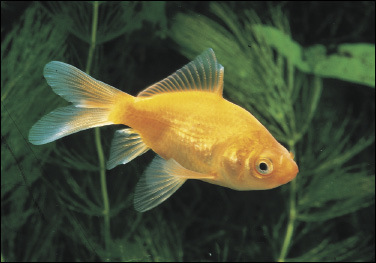

In [3]:
from IPython.display import Image, display
display(Image(IMAGE_PATH))

In [4]:
MODEL_PATH = Path("../assets/models/resnet_50_mpk.tar.gz")
LABELS_PATH = Path("../assets/imagenet_labels.txt")
MODEL_NAME = "resnet_50"
IMAGE_SIZE = 224

print("model:", MODEL_NAME)
print("model path:", MODEL_PATH)
print("model exists:", MODEL_PATH.exists())
print("labels path:", LABELS_PATH)
print("labels exists:", LABELS_PATH.exists())


model: resnet_50
model path: ../assets/models/resnet_50_mpk.tar.gz
model exists: True
labels path: ../assets/imagenet_labels.txt
labels exists: True


## Load ImageNet Labels

The ResNet-50 model returns ImageNet class scores. The labels file maps class index `0..999` to readable class names.

In [5]:
imagenet_labels = LABELS_PATH.read_text().splitlines()
print("label count:", len(imagenet_labels))
print("first labels:", imagenet_labels[:5])

label count: 1000
first labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


## ModelOptions - Configure Classification Preprocessing 

In [6]:
# Create model options for the ResNet-50 classification package.
opt = pyneat.ModelOptions()
opt.preprocess.kind = pyneat.InputKind.Image # Tell Neat that the application input is an image.
opt.preprocess.color_convert.input_format = pyneat.PreprocessColorFormat.RGB # Input image color format of the tensor 
opt.preprocess.preset = pyneat.NormalizePreset.ImageNet # Apply ImageNet normalization used by common ResNet-50 classification models.
opt.verbose = pyneat.VerboseOptions.quiet() # Suppress model-level verbose diagnostics in notebook output.
print("classification ModelOptions ready")


classification ModelOptions ready


#### Check all available option in ModelOptions

In [7]:
def public_names(obj):
    return [name for name in dir(obj) if not name.startswith("_")]

print("ModelOptions:\n", public_names(opt))
print("\nPreprocess:\n", public_names(opt.preprocess))
print("\nResize:\n", public_names(opt.preprocess.resize.mode))

ModelOptions:
 ['advanced_execution', 'boxdecode_original_height', 'boxdecode_original_width', 'boxdecode_resize_mode', 'cleanup_extracted_model_data', 'decode_type', 'decode_type_option', 'inference_terminal', 'name_suffix', 'nms_iou_threshold', 'num_classes', 'preprocess', 'processcvu', 'processmla', 'score_threshold', 'top_k', 'upstream_name', 'verbose']

Preprocess:
 ['color_convert', 'enable', 'input_max_depth', 'input_max_height', 'input_max_width', 'kind', 'layout_convert', 'normalize', 'preset', 'quantize', 'resize', 'tessellate', 'transforms']

Resize:
 ['Crop', 'Letterbox', 'Stretch', 'name', 'value']


## Prepare the Image Tensor

In [8]:
image_bgr = cv2.resize(image_bgr, (IMAGE_SIZE, IMAGE_SIZE))
image_bgr = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
tensor = pyneat.Tensor.from_numpy(image_bgr, copy=True, image_format=pyneat.PixelFormat.RGB)
print("input tensor:", tuple(tensor.shape))


input tensor: (224, 224, 3)


## Run the Model and Decode Top-3

The raw model output is a score vector. `softmax` converts those scores into probabilities across all ImageNet classes.

In [9]:
def softmax(vector):
    vector = np.asarray(vector, dtype=np.float32).reshape(-1)
    shifted = vector - np.max(vector)
    exp = np.exp(shifted)
    return exp / np.sum(exp)


def topk_predictions(scores, labels, k=3):
    scores = np.asarray(scores).reshape(-1)
    probabilities = softmax(scores)
    top_indices = np.argsort(probabilities)[-k:][::-1]
    predictions = []
    for index in top_indices:
        label = labels[index] if 0 <= index < len(labels) else f"class_{index}"
        predictions.append({
            "class_id": int(index),
            "label": label,
            "probability": float(probabilities[index]),
        })
    return predictions

In [10]:
model = pyneat.Model(str(MODEL_PATH), opt)
print(model.summary())

Model: resnet_50
  mpk: /tmp/simaai/coprocessing/models/proc_111440/resnet_50_mpk/etc/resnet_50_mpk.json
  preprocess: preproc
  postprocess: detessdequant
  outputs: 1 logical / 1 physical


In [11]:
outputs = model.run([tensor], timeout_ms=5000)
scores = outputs[0].to_numpy(copy=True)

for rank, pred in enumerate(topk_predictions(scores, imagenet_labels, k=1), start=1):
    print(
        f"#{rank}: class_id={pred['class_id']} "
        f"label={pred['label']!r} "
        f"probability={pred['probability']:.4f} "
    )


[1/4] Initializing runtime...
[2/4] Preparing input stream...
[3/4] Building graph...


#1: class_id=1 label='goldfish' probability=0.9512 


[4/4] Graph ready (523 ms)


## Remove Manual resize and color conversion 

Use ModelOptions for color convertion, resize and preprocessing 

In [16]:
opt = pyneat.ModelOptions()
opt.preprocess.kind = pyneat.InputKind.Image # Tell Neat that the application input is an image.

## Color Conversion from Model options only
opt.preprocess.color_convert.enable = pyneat.AutoFlag.On # Enable color conversion when input_format and output_format differ.
opt.preprocess.color_convert.input_format = pyneat.PreprocessColorFormat.BGR # Declare the color format of the tensor 
opt.preprocess.color_convert.output_format = pyneat.PreprocessColorFormat.RGB # Color format to hand to the model preprocessing route.

## Max Input dim setting (optional)
opt.preprocess.input_max_width = IMAGE_SIZE # Declare the maximum image width we will send into the model route.
opt.preprocess.input_max_height = IMAGE_SIZE # Declare the maximum image height we will send into the model route.
opt.preprocess.input_max_depth = 3 # Declare the maximum image channel depth this tutorial will send into the model route.

## Resize image for model
opt.preprocess.resize.enable = pyneat.AutoFlag.On # Enable resizing to the model input size when needed.
opt.preprocess.resize.width = IMAGE_SIZE # Set the resize target width expected by ResNet-50.
opt.preprocess.resize.height = IMAGE_SIZE # Set the resize target height expected by ResNet-50.
opt.preprocess.resize.mode = pyneat.ResizeMode.Stretch

# ImageNet Normalization
opt.preprocess.preset = pyneat.NormalizePreset.ImageNet # Apply ImageNet normalization used by common ResNet-50 classification models.

opt.verbose = pyneat.VerboseOptions.quiet() # Suppress model-level verbose diagnostics in notebook output.

print("classification ModelOptions ready")


classification ModelOptions ready


In [17]:
image_bgr = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_COLOR)
tensor = pyneat.Tensor.from_numpy(image_bgr, copy=True, image_format=pyneat.PixelFormat.BGR)

In [18]:
model = pyneat.Model(str(MODEL_PATH), opt)
print(model.summary())

Model: resnet_50
  mpk: /tmp/simaai/coprocessing/models/proc_111440/resnet_50_mpk/etc/resnet_50_mpk.json
  preprocess: preproc
  postprocess: detessdequant
  outputs: 1 logical / 1 physical


In [19]:
outputs = model.run([tensor], timeout_ms=5000)
scores = outputs[0].to_numpy(copy=True)

for rank, pred in enumerate(topk_predictions(scores, imagenet_labels, k=1), start=1):
    print(
        f"#{rank}: class_id={pred['class_id']} "
        f"label={pred['label']!r} "
        f"probability={pred['probability']:.4f} "
    )


#1: class_id=1 label='goldfish' probability=0.9572 


[1/4] Initializing runtime...
[2/4] Preparing input stream...
[3/4] Building graph...
[4/4] Graph ready (65 ms)


## References

- Public tutorial collection: [core/tutorials](https://github.com/sima-neat/core/tree/main/tutorials).
- Core source: [run_your_first_model.py](https://github.com/sima-neat/core/blob/main/tutorials/001_run_your_first_model/run_your_first_model.py).
- Apps example: [image-classifier README](https://github.com/sima-neat/apps/blob/main/examples/classification/image-classifier/README.md).
- Model Zoo tool docs: [model-zoo.md](https://github.com/sima-neat/core/blob/main/docs/tools/model-zoo.md).
- ImageNet labels text file source: [imagenet_classes.txt](https://github.com/pytorch/hub/blob/master/imagenet_classes.txt).